# Forest Fires







Людвиковская А.В. Б05-875

liudvikovskaia.av@phystech.edu








```
# Enter your mail: liudvikovskaia.av@phystech.edu
{'dataset': {'name': 'Forest Fires Data Set',
  'url': 'https://archive.ics.uci.edu/ml/datasets/Forest+Fires'},
 'id': 234590212,
 'mail': 'liudvikovskaia.av@phystech.edu',
 'method': ['Перцептрон', 'Линейная регрессия', 'SVR'],
 'type': 'regression'}
```




Данные взяты из https://archive.ics.uci.edu/ml/datasets/Forest+Fires






Библиотеки и прочее:

In [1]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    !wget -q -O requirements.txt https://raw.githubusercontent.com/ArcasHH/ML/main/requirements2.txt
    !pip install -q -r requirements2.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements2.txt'


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Perceptron
from sklearn.svm import SVR


import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
import seaborn as sns
from sklearn import preprocessing
from sklearn import linear_model
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import explained_variance_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

from sklearn.decomposition import PCA

from sklearn.pipeline import make_pipeline

import numpy as np
import pandas as pd
import torch
import torch.utils.data as data_utils
from tqdm.notebook import tqdm

# Анализ

In [3]:
dataset = pd.read_csv('https://raw.githubusercontent.com/ArcasHH/ML/main/ff.csv', 
                      header=None, 
                      names=['X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area'])
dataset.sample(10, random_state=0)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
213,7,3,mar,mon,87.6,52.2,103.8,5.0,11.0,46,5.8,0.0,27.35
435,2,5,jul,sat,90.8,84.7,376.6,5.6,23.8,51,1.8,0.0,0.00
343,8,6,sep,mon,91.5,130.1,807.1,7.5,15.9,51,4.5,0.0,2.18
230,4,4,sep,wed,92.9,133.3,699.6,9.2,26.4,21,4.5,0.0,88.49
171,8,6,aug,wed,85.6,90.4,609.6,6.6,17.4,50,4.0,0.0,2.69
15,6,5,sep,fri,93.3,141.2,713.9,13.9,22.9,44,5.4,0.0,0.00
162,6,3,mar,sat,90.6,50.1,100.4,7.8,15.2,31,8.5,0.0,1.94
489,4,4,aug,wed,95.1,141.3,605.8,17.7,20.6,58,1.3,0.0,0.00
381,8,6,aug,thu,90.7,194.1,643.0,6.8,16.2,63,2.7,0.0,16.33
96,3,4,feb,sat,83.9,8.0,30.2,2.6,12.7,48,1.8,0.0,0.00




1. **X** на карте парка Монтесиньо: от 1 до 9
2. **Y** на карте парка Монтесиньо: от 2 до 9
3. **month** - месяц года: с "января" по "декабрь"
4. **day** - день недели
5. **FFMC** - индекс FFMC от системы FWI: от 18,7 до 96,20
6. **DMC** - Индекс DMC от системы FWI: от 1,1 до 291,3
7. **DC** - Индекс DC от системы FWI: от 7,9 до 860,6
8. **ISI** - Индекс ISI от системы FWI: от 0,0 до 56,10
9. **temp** - температура в градусах Цельсия: от 2,2 до 33,30
10. **RH** - относительная влажность в %: от 15,0 до 100
11. **wind** - скорость ветра в км/ч: от 0,40 до 9,40
12. **rain** - наружный дождь в мм/м2: от 0,0 до 6,4

13. **area** - площадь выгоревшего леса (в га): от 0,00 до 1090,84



Будем предсказывать площадь пожаров: 'area'

In [4]:
print('Размер выборки составляет l={} объектов.'.format(len(dataset)))

Размер выборки составляет l=517 объектов.



Мощность множества ответов $|Y| \approx 1090$ ~ $l = 517$. Задача регрессии.



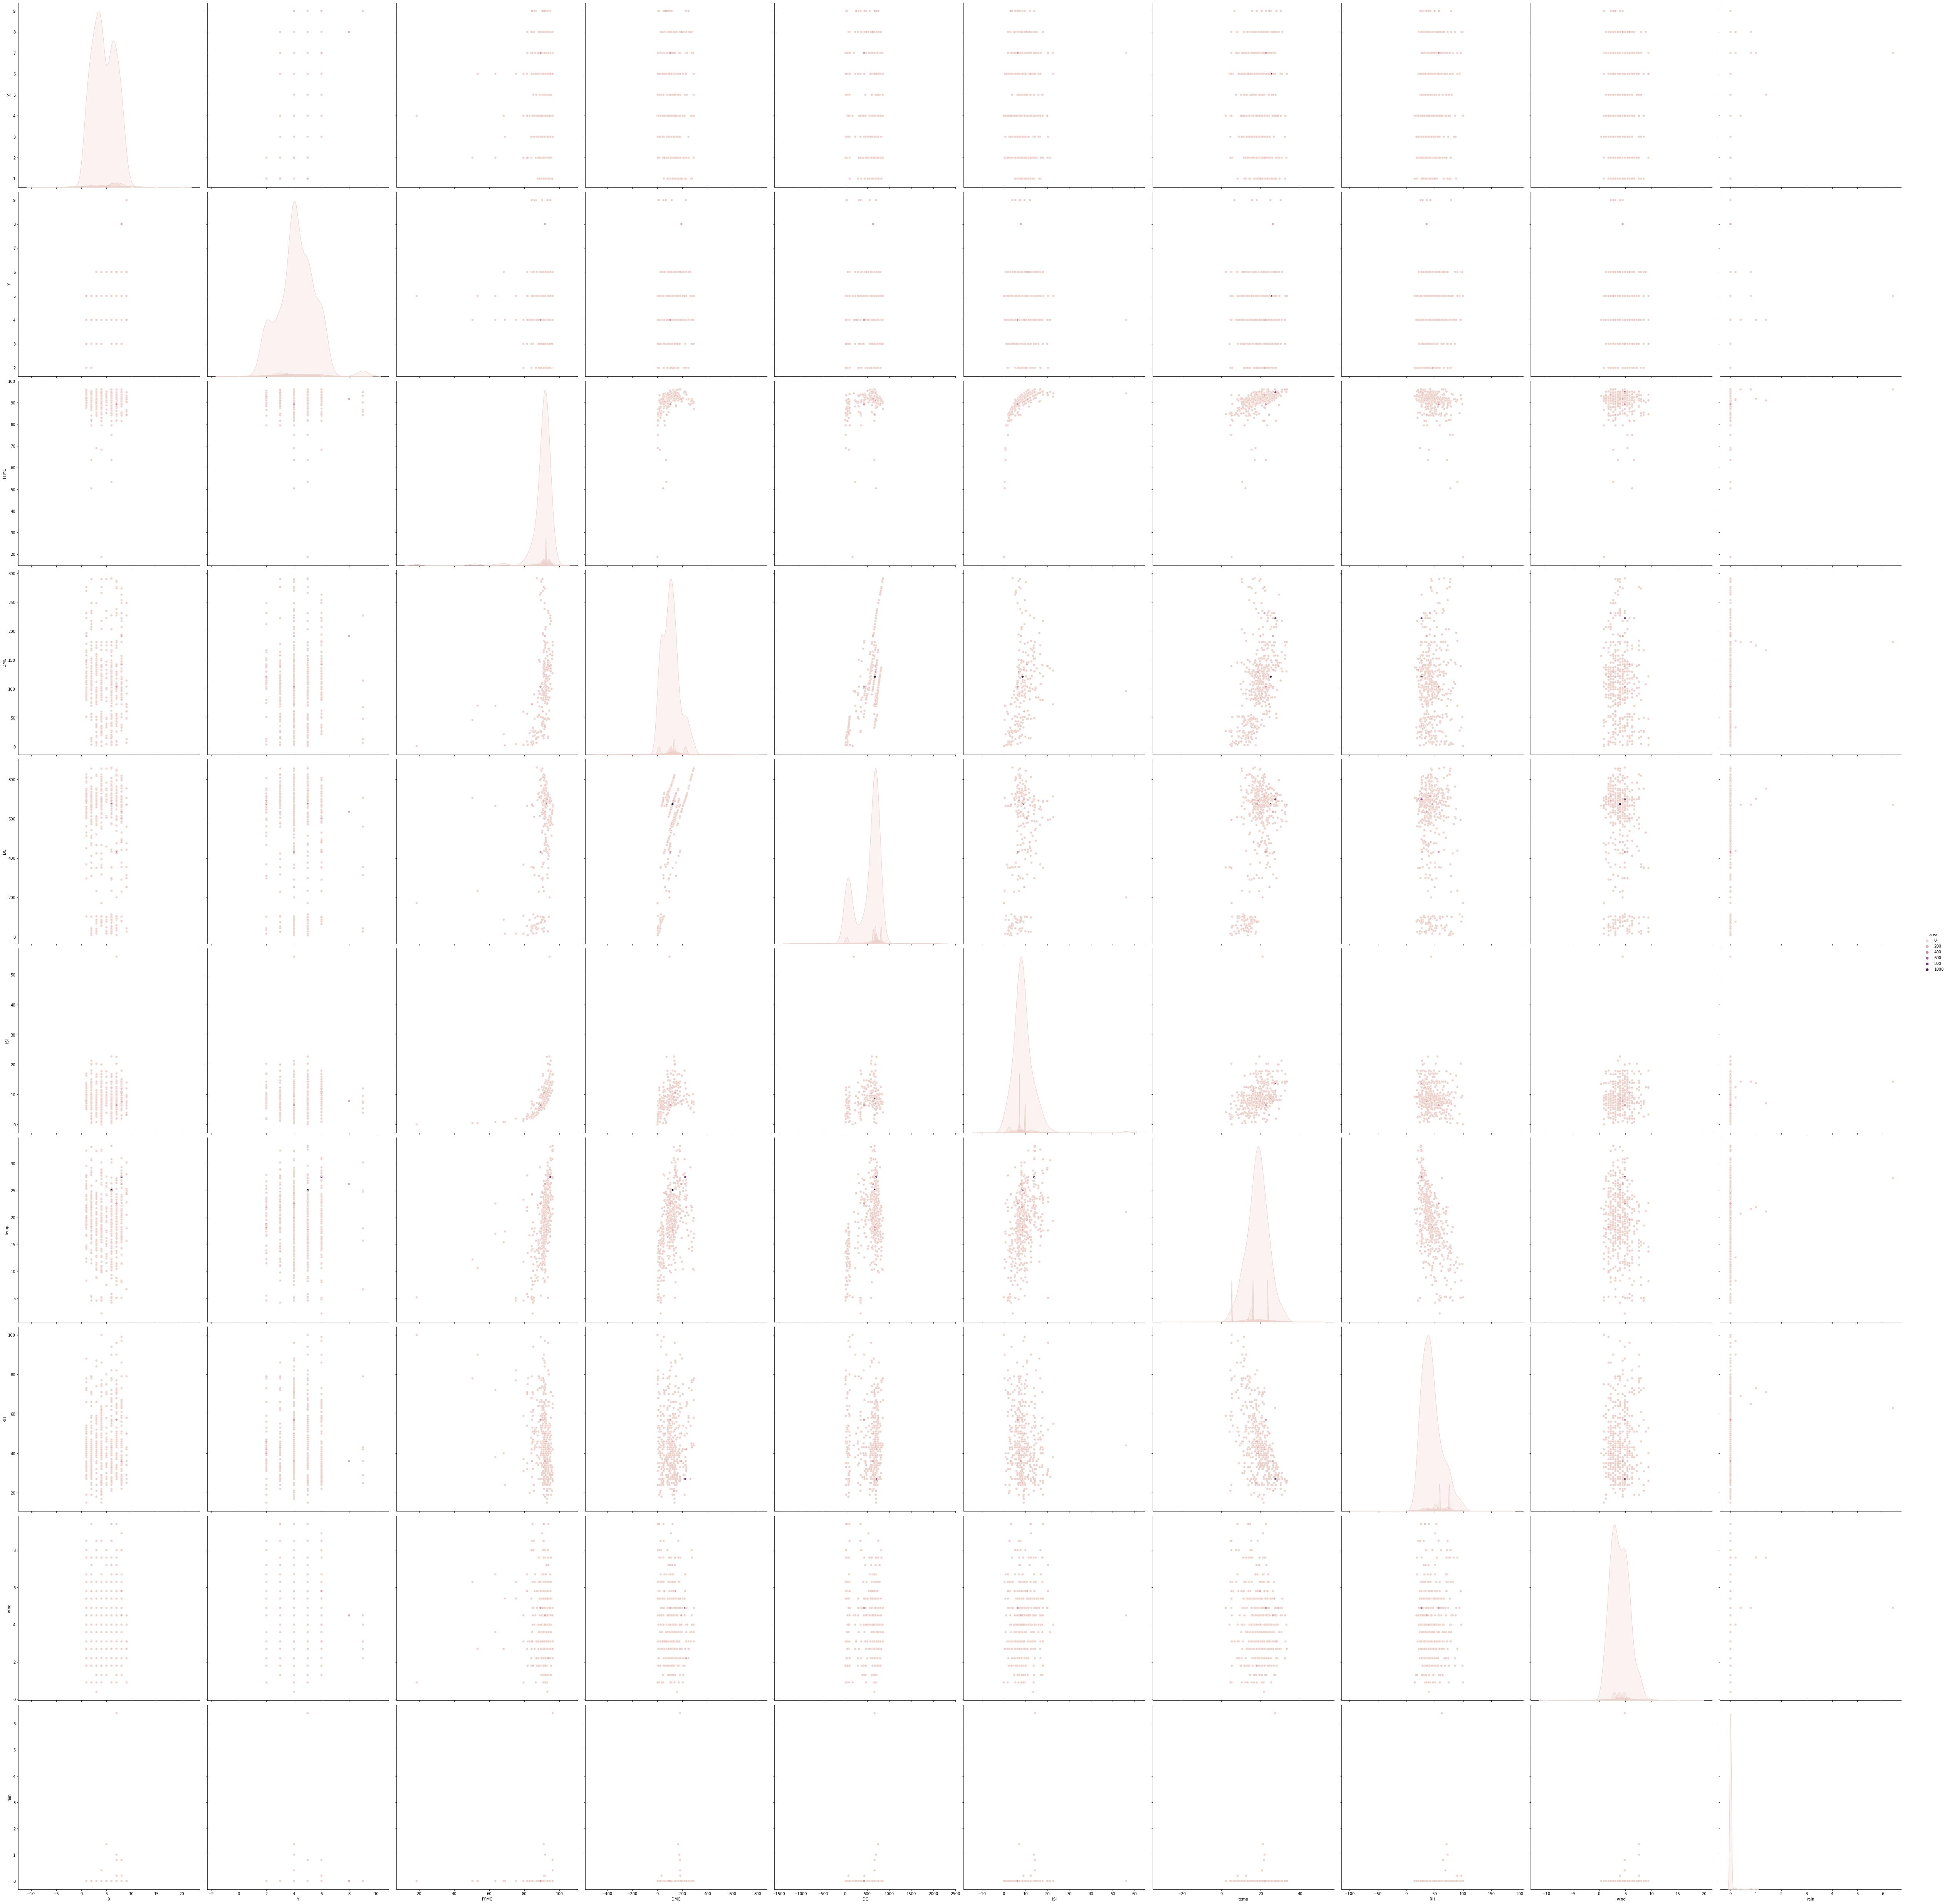

In [5]:
sns.pairplot(dataset, hue='area', height=7)
plt.show()

Видим очень много нулевых значений для площади пожаров

In [6]:
dataset['month'] = pd.Categorical(dataset['month']).codes   #преобразуем данные в числовые
dataset['day'] = pd.Categorical(dataset['day']).codes

Y=dataset[['area']]    #target
X=dataset[['X',	'Y',	'month', 'day','FFMC',	'DMC',	'DC',	'ISI',	'temp',	'RH',	'wind',	'rain']]   #data

print('Y:\n',Y)
Y=np.log(1+Y)  #(this output variable is very skewed towards 0.0, thus it may make sense to model with the logarithm transform)
print('Y:\n',Y)

X = preprocessing.normalize(X, norm='l1')  #нормализуем

print(' X:\n', X)

Y:
       area
0     0.00
1     0.00
2     0.00
3     0.00
4     0.00
..     ...
512   6.44
513  54.29
514  11.16
515   0.00
516   0.00

[517 rows x 1 columns]
Y:
          area
0    0.000000
1    0.000000
2    0.000000
3    0.000000
4    0.000000
..        ...
512  2.006871
513  4.012592
514  2.498152
515  0.000000
516  0.000000

[517 rows x 1 columns]
 X:
 [[0.02359285 0.01685204 0.02359285 ... 0.1718908  0.02258173 0.        ]
 [0.00795726 0.004547   0.01136751 ... 0.03751279 0.00102308 0.        ]
 [0.00777951 0.00444543 0.01111358 ... 0.03667482 0.00144477 0.        ]
 ...
 [0.00761946 0.00435398 0.00108849 ... 0.07619462 0.00729291 0.        ]
 [0.00105708 0.00422833 0.00105708 ... 0.04439746 0.00422833 0.        ]
 [0.02302379 0.0115119  0.03453569 ... 0.11895625 0.01726784 0.        ]]


In [7]:
print("Statistical Description:\n", dataset.describe())

Statistical Description:
                 X           Y       month  ...        wind        rain         area
count  517.000000  517.000000  517.000000  ...  517.000000  517.000000   517.000000
mean     4.669246    4.299807    5.758221  ...    4.017602    0.021663    12.847292
std      2.313778    1.229900    4.373275  ...    1.791653    0.295959    63.655818
min      1.000000    2.000000    0.000000  ...    0.400000    0.000000     0.000000
25%      3.000000    4.000000    1.000000  ...    2.700000    0.000000     0.000000
50%      4.000000    4.000000    6.000000  ...    4.000000    0.000000     0.520000
75%      7.000000    5.000000   11.000000  ...    4.900000    0.000000     6.570000
max      9.000000    9.000000   11.000000  ...    9.400000    6.400000  1090.840000

[8 rows x 13 columns]


Посмотрим на зависимость площади от каждого из признаков:

i= 0


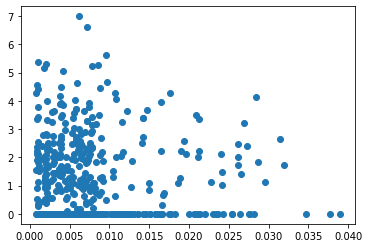

<Figure size 72x72 with 0 Axes>

i= 1


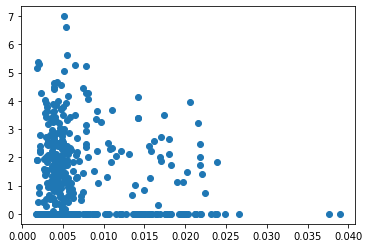

<Figure size 72x72 with 0 Axes>

i= 2


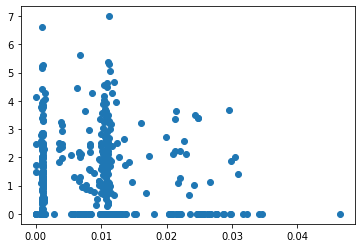

<Figure size 72x72 with 0 Axes>

i= 3


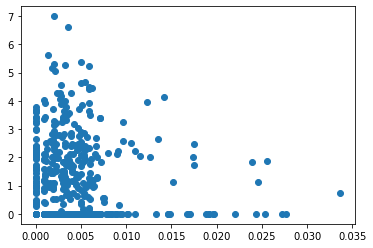

<Figure size 72x72 with 0 Axes>

i= 4


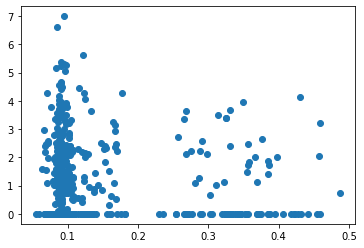

<Figure size 72x72 with 0 Axes>

i= 5


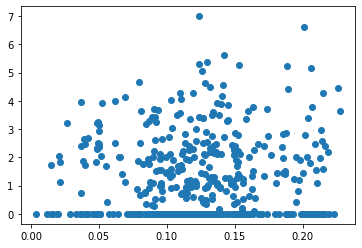

<Figure size 72x72 with 0 Axes>

i= 6


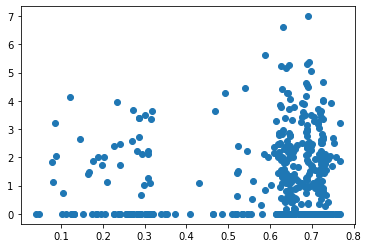

<Figure size 72x72 with 0 Axes>

i= 7


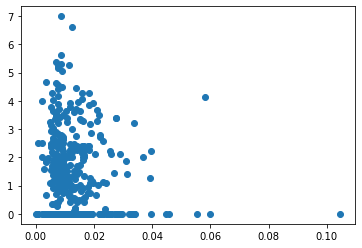

<Figure size 72x72 with 0 Axes>

i= 8


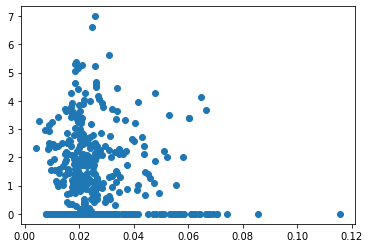

<Figure size 72x72 with 0 Axes>

i= 9


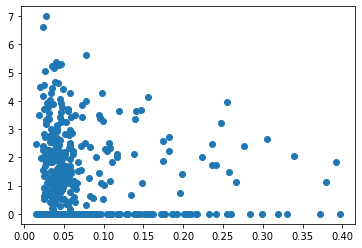

<Figure size 72x72 with 0 Axes>

i= 10


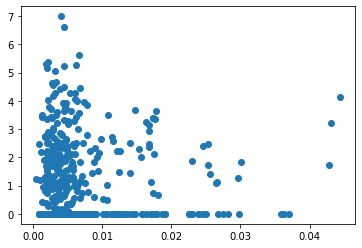

<Figure size 72x72 with 0 Axes>

i= 11


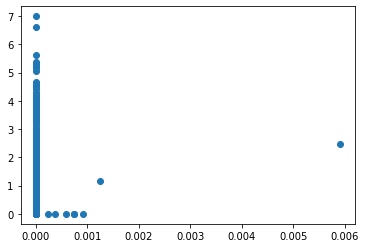

<Figure size 72x72 with 0 Axes>

In [8]:
for i in range(12):
  plt.plot(X[:, i], Y, 'o')
  print('i=',i)
  plt.figure(figsize=(1, 1))
  plt.show()

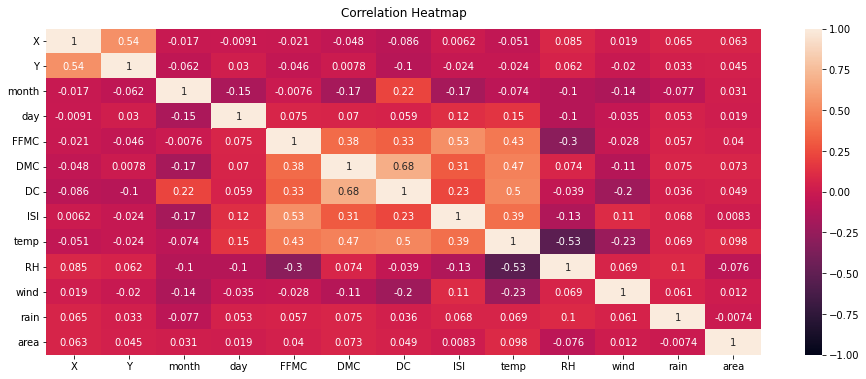

In [9]:
plt.figure(figsize=(16, 6))
heatmap = sns.heatmap(dataset.corr(), vmin=-1, vmax=1, annot=True) 

heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':12}, pad=12);

temp имеет самую высокую корреляцию с площадью лесного пожара.
от RH площадь зависит меньше всего

Но в целом целевой признак мало зависит от остальных параметров

# LinearRegression

$$
\mathfrak{F}_{rg} = \{f\bigr(\mathbf{w}, \mathbf{x}\bigr) = \mathbf{w}^{\mathsf{T}}\mathbf{x}| \mathbf{w}\in \mathbb{R}^{n}\}.
$$
$$
 \hat{\mathbf{w}} = \left(\mathbf{X}^{\mathsf{T}}\mathbf{X}\right)^{-1}\mathbf{X}^{\mathsf{T}}\mathbf{y}
$$





In [10]:
model = LinearRegression()
model.fit(X, Y)
pred = model.predict(X)

print('коеффициенты:\n', model.coef_)

print('pred:\n',pred)

коеффициенты:
 [[ 44.33566348 -52.513961   -10.04416531  -5.06035658  -6.48617963
   -6.08230175  -7.38718254 -19.47125558 -19.48144843 -10.3691245
   15.81061113  76.74970071]]


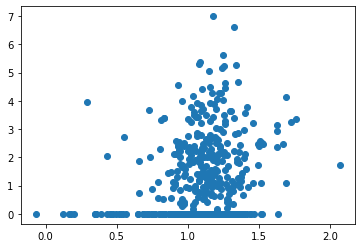

In [11]:
plt.scatter(pred ,Y)
plt.show()

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=150, shuffle=True )

         area
0    1.519241
1    1.182886
2    1.245252
3    0.871508
4    0.687714
..        ...
512  1.084038
513  0.958452
514  1.276589
515  0.927148
516  1.637159

[517 rows x 1 columns]


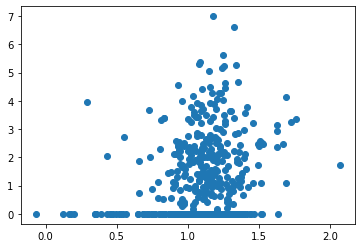

In [13]:
w = np.linalg.inv(X.T@X)@X.T@Y
   #условие первого порядка

train=X@w
print(train)
plt.scatter(train ,Y)
plt.show()

In [14]:
score = explained_variance_score(Y, pred)
mae = mean_absolute_error(pred, Y)
mse = mean_squared_error(pred, Y)
print('mae for pred =',mae)
print('score for pred =',score)
print('mse for pred =',mse)

mae for pred = 1.1265748541266334
score for pred = 0.0303732229022049
mse for pred = 1.892556799952597


In [15]:
"""
score = explained_variance_score(Y, train)
mae = mean_absolute_error(train, Y)
mse = mean_squared_error(train, Y)
print('mae for train =',mae)
print('score for train =',score)
print('mse for pred =',mse)
"""

"\nscore = explained_variance_score(Y, train)\nmae = mean_absolute_error(train, Y)\nmse = mean_squared_error(train, Y)\nprint('mae for train =',mae)\nprint('score for train =',score)\nprint('mse for pred =',mse)\n"

In [16]:
means = np.mean(X_train, axis=0)
stds = np.std(X_train, axis=0)
X_train = (X_train - means)/stds
X_test = (X_test - means)/stds

-0.05097012312162352


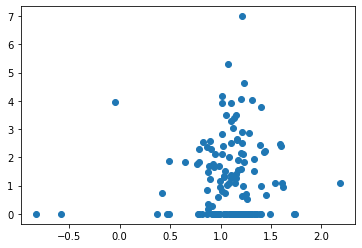

In [17]:
model = LinearRegression()
model.fit (X_train, Y_train)
plt.scatter(model.predict(X_test), Y_test)
print(model.score(X_test, Y_test))
plt.show()

тоже ничего хорошего


# Perceptron

In [18]:
target = torch.tensor(Y.values)
features = torch.tensor(X)
print (target.shape, features.shape)
target = target.float().view(-1, 1)
features = features.float()

train = data_utils.TensorDataset(features, target)
train_loader = data_utils.DataLoader(train, batch_size=10, shuffle=True)


torch.Size([517, 1]) torch.Size([517, 12])


In [19]:
X_train_tensor = torch.from_numpy(X_train)
X_test_tensor = torch.from_numpy(X_test)
Y_tr=Y_train.to_numpy()
Y_tt=Y_train.to_numpy()
Y_train_tensor = torch.from_numpy(Y_tr)
Y_test_tensor = torch.from_numpy(Y_tt)

In [20]:
class Perceptron(torch.nn.Module):
    @property
    def device(self):
        for p in self.parameters():
            return p.device

    def __init__(self, input_dim=12, num_layers=0, 
                 hidden_dim=12, output_dim=1, p=0.0):
        super(Perceptron, self).__init__()
        
        self.layers = torch.nn.Sequential()
        
        prev_size = input_dim
        for i in range(num_layers):
            self.layers.add_module('layer{}'.format(i), 
                                  torch.nn.Linear(prev_size, hidden_dim))
            self.layers.add_module('relu{}'.format(i), torch.nn.ReLU())
            self.layers.add_module('dropout{}'.format(i), torch.nn.Dropout(p=p))
            prev_size = hidden_dim
        
        self.layers.add_module('linear', 
                               torch.nn.Linear(prev_size, output_dim))        
        
    def forward(self, input):
        return self.layers(input)

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [22]:
model = Perceptron(num_layers=3)
model.to(device)

Perceptron(
  (layers): Sequential(
    (layer0): Linear(in_features=12, out_features=12, bias=True)
    (relu0): ReLU()
    (dropout0): Dropout(p=0.0, inplace=False)
    (layer1): Linear(in_features=12, out_features=12, bias=True)
    (relu1): ReLU()
    (dropout1): Dropout(p=0.0, inplace=False)
    (layer2): Linear(in_features=12, out_features=12, bias=True)
    (relu2): ReLU()
    (dropout2): Dropout(p=0.0, inplace=False)
    (linear): Linear(in_features=12, out_features=1, bias=True)
  )
)

In [23]:
def testing(model, dataset):
    generator = torch.utils.data.DataLoader(dataset, batch_size=442)

    pred = []
    real = []
    for x, y in generator:
        x = x.view([-1, 12]).to(device)
        y = y.to(device)

        pred.extend(model(x).detach().cpu().numpy().tolist())
        real.extend(y.cpu().numpy().tolist())

    return mean_squared_error(real, pred)

In [24]:
def trainer(model, dataset, loss_function, optimizer, epochs):
    for epoch in tqdm(range(epochs), leave=True):
        generator = torch.utils.data.DataLoader(dataset, batch_size=442, 
                                              shuffle=True)
        for x, y in generator:
            optimizer.zero_grad()
            x = x.view([-1, 12]).to(device)
            y = y.to(device)

            output = model(x).view(-1,1)
            loss = loss_function(output, y)
            loss.backward()
            optimizer.step()

In [25]:
def draw_table(data, title=['MSE'], width=[60, 11]):    
    row_format = '|' + '|'.join([("{:>"+str(w)+"}") for w in width]) + '|'
    row_format_bet = '+' + '+'.join([("{:>"+str(w)+"}") for w in width]) + '+'
    
    print(row_format_bet.format(
        "-"*width[0], *["-"*width[i+1] for i, _ in enumerate(title)]))
    print(row_format.format("", *title))
    print(row_format_bet.format(
        "-"*width[0], *["-"*width[i+1] for i, _ in enumerate(title)]))
    for key in data:
        if len(key) > width[0]:
            row_name = '...' + key[len(key)-width[0]+3:]
        else:
            row_name = key
        print(row_format.format(row_name, *[round(x, 2) for x in data[key]]))
        print(row_format_bet.format(
            "-"*width[0], *["-"*width[i+1] for i, _ in enumerate(title)]))

In [26]:
_ = model.eval()
mse = testing(model, train)
print(mse)

3.653431843979156


In [27]:
_ = model.train()
trainer(model=model, 
        dataset=train, 
        loss_function=torch.nn.MSELoss(), 
        optimizer=torch.optim.Adam(model.parameters(), lr=0.001), 
        epochs=6)

  0%|          | 0/6 [00:00<?, ?it/s]

In [28]:
_ = model.eval()
mse = testing(model, train)
print(np.average(mse))

3.499722625525475


Не сильно изменилось значение ошибки mse

In [29]:
generator = torch.utils.data.DataLoader(train, batch_size=442, 
                                              shuffle=True)
pred = []
real = []
for x, y in generator:
  x = x.view([-1, 12]).to(device)
  y = y.to(device)
  pred.extend(model(x).detach().cpu().numpy().tolist())
  real.extend(y.cpu().numpy().tolist())

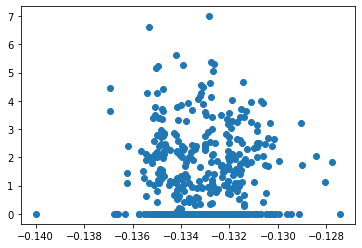

In [30]:
plt.scatter(pred, real)
plt.show()

подберем гиперпараметры:

In [31]:
cross_val = KFold(3)
number_of_batch = cross_val.get_n_splits(train)

grid = ParameterGrid({'num_layers': [0, 2, 4], 
                      'hidden_dim': [12,96],
                      'p': [0.2, 0.8],
                      'lr': [0.001]})

In [32]:
mse = dict()
for item in tqdm(grid):
    list_of_mse = []
    for train_index, test_index in tqdm(cross_val.split(X_train_tensor), 
                                        total=number_of_batch, leave=False):
        x_train_fold = X_train_tensor[train_index].float()
        x_test_fold = X_train_tensor[test_index].float()
        y_train_fold = Y_train_tensor[train_index].float().view(-1, 1)
        y_test_fold = Y_train_tensor[test_index].float().view(-1,1)

        traindata = torch.utils.data.TensorDataset(x_train_fold, y_train_fold)
        testdata = torch.utils.data.TensorDataset(x_test_fold, y_test_fold)

        model = Perceptron(num_layers=item['num_layers'], p=item['p'],
                           hidden_dim=item['hidden_dim'])
        model.to(device)
        _ = model.train()
        trainer(model=model, 
                dataset=traindata, 
                loss_function=torch.nn.MSELoss(), 
                optimizer=torch.optim.Adam(model.parameters(), lr=item['lr']), 
                epochs=1000)
        
        _ = model.eval()
        scr = testing(model, testdata)
        list_of_mse.append(scr)
    mse[str(item)] = [np.mean(list_of_mse)]

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

In [33]:
draw_table(mse)


+------------------------------------------------------------+-----------+
|                                                            |        MSE|
+------------------------------------------------------------+-----------+
|  {'hidden_dim': 12, 'lr': 0.001, 'num_layers': 0, 'p': 0.2}|       2.43|
+------------------------------------------------------------+-----------+
|  {'hidden_dim': 12, 'lr': 0.001, 'num_layers': 0, 'p': 0.8}|       2.54|
+------------------------------------------------------------+-----------+
|  {'hidden_dim': 12, 'lr': 0.001, 'num_layers': 2, 'p': 0.2}|       2.18|
+------------------------------------------------------------+-----------+
|  {'hidden_dim': 12, 'lr': 0.001, 'num_layers': 2, 'p': 0.8}|       2.04|
+------------------------------------------------------------+-----------+
|  {'hidden_dim': 12, 'lr': 0.001, 'num_layers': 4, 'p': 0.2}|       2.46|
+------------------------------------------------------------+-----------+
|  {'hidden_dim': 12, 'lr

Модель обучается, но не как хотелось.

**Гиперпараметры**

Заметим, что на линейной регрессии оценка хуже. 
Для 'hidden_dim'=12 лучше всего работает, как идля p=0.8 , num_layers не сильно влияет

# SVR

In [34]:
param = {'kernel' : ('linear', 'poly', 'rbf'),'C' : [1,5,10],'coef0' : [0.01,10,0.5],'gamma' : ('auto','scale')},
model = SVR()
grids = GridSearchCV(model,param,cv=3, n_jobs =-1, verbose = 2)
grids.fit(X_train,Y_train)

print('grids.best_params_',grids.best_params_,'\n')
print('grids.best_score_',grids.best_score_,'\n')

Fitting 3 folds for each of 54 candidates, totalling 162 fits
grids.best_params_ {'C': 1, 'coef0': 0.01, 'gamma': 'scale', 'kernel': 'rbf'} 

grids.best_score_ -0.24775556138257407 



/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:985: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


mse = 2.2743364666071724
mae = 1.0654484701983604


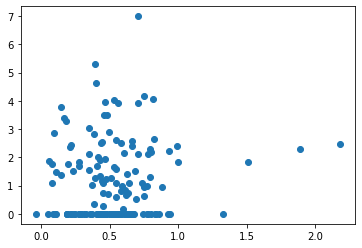

In [35]:
plt.scatter(grids.predict(X_test),Y_test)


mse = mean_squared_error(grids.predict(X_test),Y_test)
print('mse =',mse)
mae = mean_absolute_error(grids.predict(X_test),Y_test)
print('mae =',mae)

# Вывод




1.   Какая модель лучше и почему. Оценивая по mse Linear_regression выглядит лучше. SVR обучается хуже чем linear_regression и perceptron.
Возможно можно было бы улучшить оценку для персептрона, если более тщательно подбирать гиперпараметры



2.   С какими проблемами столкнулись во время выполнения, возможно недочеты стандартных библиотек.
 

3.   Совпадают ли полученные результаты с ожидаемыми результатами.
Этот набор данных не подходит для прогнозирования площади лесных пожаров. 

На данной выборки плохо получается предсказать площадь будущих пожаров, тк большенство элементов с нулевым target('area'=0). Также area плохо коррелирует с остальными признаками. Также хотелось бы видеть большую выборку для лучшей точности